<a href="https://colab.research.google.com/github/xvillarreald-max/AF2_DATA_PROCESSING/blob/main/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT 2: Processing Datasets in Python**

Ximena Villarreal Dávila

ID: 2177714

Class Schedule: V6


Benito Woo Zozaya

ID: 2177866

Class Schedule: N1


David Palma Cabañez

ID: 2177805

Class Schedule: N1


Carlos Arturo Arguelles Segura

ID: 2096281

Class Schedule: N1


PART 1: Data Loading and exploration

First we need to import the necessary libraries and load the dataset

In [ ]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt

We need the kagglehub library so we can download the dataset directly from Kaggle

In [ ]:
# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

#Use pandas to load the CSV file
url = path + "/diabetes.csv"
df = pd.read_csv(url)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


Then we display the first few rows of the dataset

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Then we need to identify the null or inconsistent values, this dataset uses cero to replace the inconsistent values, so first we need to transform this ceros to a null that python detects.

In [ ]:
#The columns that are not listed in the cleansing are because the value cero is a valid number and not a null or inconsistent value.
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[columns_to_clean] = df[columns_to_clean].replace(0, np.nan)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Then we need to generate descriptive statistics

In [ ]:
statistics = df.describe().T
print(statistics)

                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   763.0  121.686763   30.535641  44.000  99.00000   
BloodPressure             733.0   72.405184   12.382158  24.000  64.00000   
SkinThickness             541.0   29.153420   10.476982   7.000  22.00000   
Insulin                   394.0  155.548223  118.775855  14.000  76.25000   
BMI                       757.0   32.457464    6.924988  18.200  27.50000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.24375   
Age                       768.0   33.240885   11.760232  21.000  24.00000   
Outcome                   768.0    0.348958    0.476951   0.000   0.00000   

                               50%        75%     max  
Pregnancies                 3.0000    6.00000   17.00  
Glucose                   117.0000  141.00000  199.00  
BloodPressure              72.0000   80.00000  122.00  
SkinT

PART 2: Data Cleansing and Normalization

We need to replace the inconsistent values with the median of each column

In [ ]:
df.fillna(df.median())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


Normalizing the numerical data using Min-Max Scaling

Python uses a mathematic formula to normalize the data, we can implement this formula with pandas.

*Xscaled= (x-xmin)/(xmax-xmin)*

This normalization transforms the values of a column so they can all be in a specific range of values, usually between 0 and 1.

In [ ]:
df_scaled = (df - df.min())/(df.max() - df.min())

We can display the fisrt rows to verify that it is correctly scaled.

In [ ]:
df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,NaN,0.314928,0.234415,0.483333,1.0
1,0.058824,0.264516,0.428571,0.239130,NaN,0.171779,0.116567,0.166667,0.0
2,0.470588,0.896774,0.408163,NaN,NaN,0.104294,0.253629,0.183333,1.0
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0.0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1.0


In [ ]:
#Another form to verify is using the .describe() function
#The min values are all 0 and thde max values are all 1 (the range in which the values are all within)
df_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,0.226180,0.501205,0.493930,0.240798,0.170130,0.291564,0.168179,0.204015,0.348958
std,0.198210,0.197004,0.126349,0.113880,0.142759,0.141615,0.141473,0.196004,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.354839,0.408163,0.163043,0.074820,0.190184,0.070773,0.050000,0.000000
50%,0.176471,0.470968,0.489796,0.239130,0.133413,0.288344,0.125747,0.133333,0.000000
75%,0.352941,0.625806,0.571429,0.315217,0.211538,0.376278,0.234095,0.333333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


PART 3: Data Visualization

Histogram of glucose levels

Before Normalization

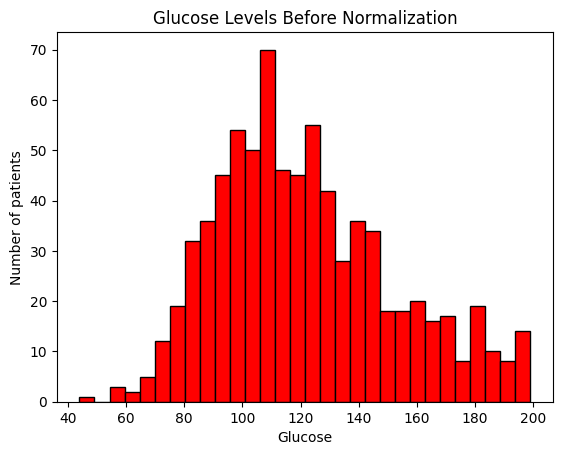

In [ ]:
plt.figure()
plt.hist(df['Glucose'], bins = 30, color = 'red', edgecolor = 'black')
plt.title("Glucose Levels Before Normalization")
plt.xlabel("Glucose")
plt.ylabel("Number of patients")
plt.show()

After Normalization

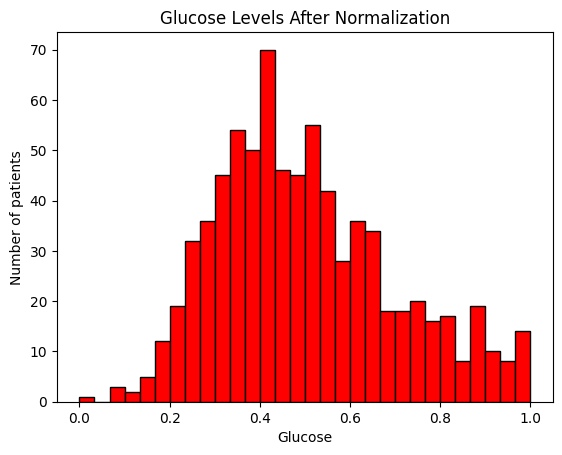

In [ ]:
plt.figure()
plt.hist(df_scaled['Glucose'], bins = 30, color = 'red', edgecolor = 'black')
plt.title("Glucose Levels After Normalization")
plt.xlabel("Glucose")
plt.ylabel("Number of patients")
plt.show()

Boxplot to identify outliers in blood pressure

Boxplot Before Normalization

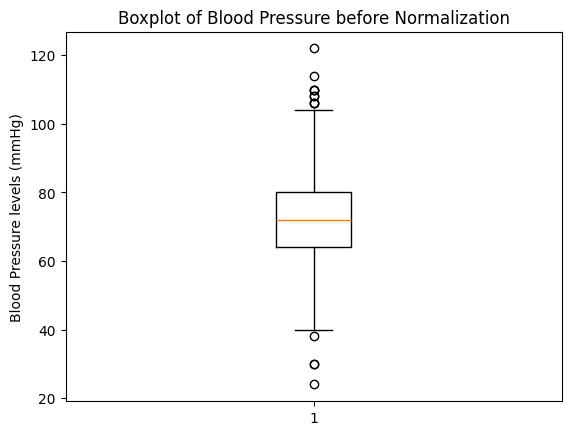

In [ ]:
plt.figure()
plt.boxplot(df['BloodPressure'].dropna())
plt.title ("Boxplot of Blood Pressure before Normalization")
plt.ylabel ("Blood Pressure levels (mmHg)")
plt.show()

Boxplot After Normalization

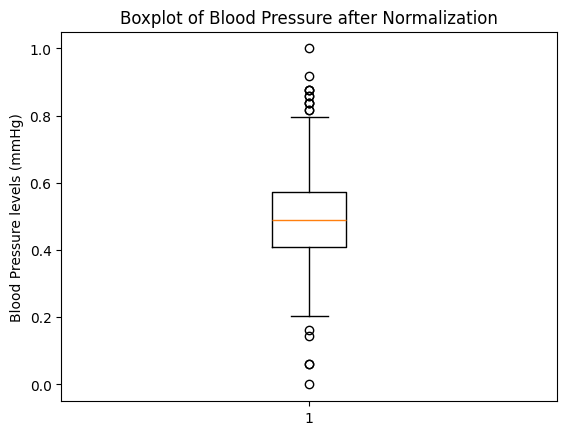

In [ ]:
plt.figure()
plt.boxplot(df_scaled['BloodPressure'].dropna())
plt.title ("Boxplot of Blood Pressure after Normalization")
plt.ylabel ("Blood Pressure levels (mmHg)")
plt.show()

Scatter plot between Glucose and BMI to show correlation.

Scatter Plot before normalization

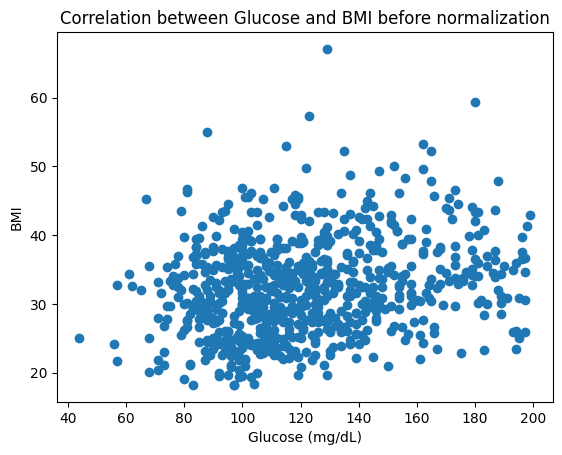

In [ ]:
plt.figure()
plt.scatter(df['Glucose'],df['BMI'])
plt.title("Correlation between Glucose and BMI before normalization")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI")
plt.show()


Scatterplot between Glucose and BMI After Normalization

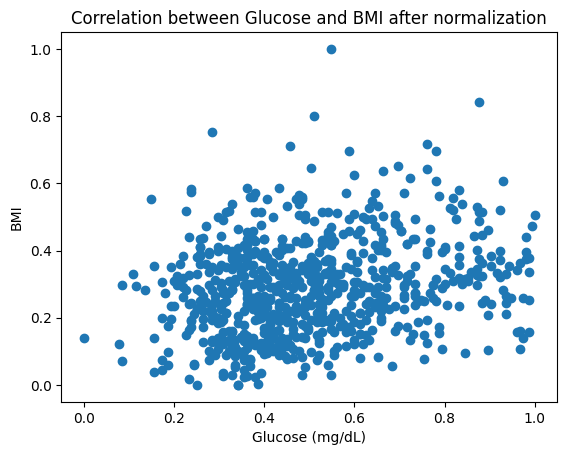

In [ ]:
plt.figure()
plt.scatter(df_scaled['Glucose'],df_scaled['BMI'])
plt.title("Correlation between Glucose and BMI after normalization")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI")
plt.show()

Bar chart showing the number of patients with and without diabetes.



First we need to make like an "average" of one variable so we can compare it with other groups, in this case we can make a Glucose average between the people who has diabetes (Outcome 1) and the people who don't (Outcome 0)

In [ ]:
glucose_avg= df.groupby('Outcome')['Glucose'].mean()
print(glucose_avg)

Outcome
0    110.643863
1    142.319549
Name: Glucose, dtype: float64


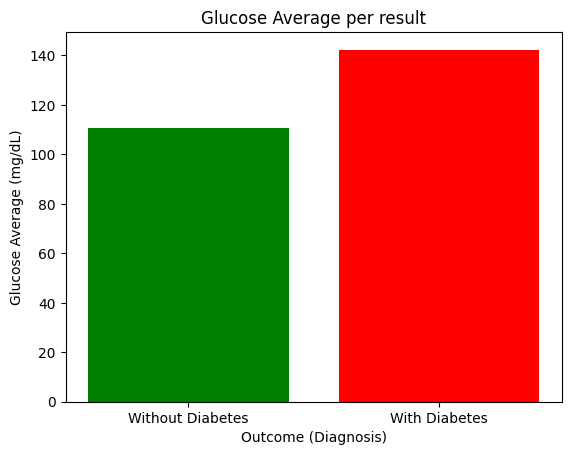

In [ ]:
plt.figure()
plt.bar(['Without Diabetes', 'With Diabetes'], glucose_avg, color=['green', 'red'])
plt.title("Glucose Average per result")
plt.xlabel("Outcome (Diagnosis)")
plt.ylabel("Glucose Average (mg/dL)")
plt.show()

PART 4: Answer the following questions

**1- What impact do missing values have on data analysis?**

Missing values can severely compromise the integrity of data analysis by reducing statistical power and introducing bias. If rows with missing data are simply deleted, you might lose critical information about specific patient demographics or disease severities, resulting in a model that fails to generalize to real-world clinical scenarios.

**2- How can we detect and handle outliers in biomedical datasets?**

**Detection:** Outliers are typically detected using statistical methods lize
Z-scores or the Interquartile Range method. Visualizations like box plots and scatter plots are also highly effective for spotting anomalies.

**Handling:** In biomedical data, handling outliers requires caution because and extreme value might represent a valid, severe physiological state rather than a measurement error. If an outlier is an obvious error, it should be treated as missing data and imputed or removed. If it represents true biological variability, techniques like capping or applying a log transformation are often preferred over deletion to preserve the data's integrity.

**3- What are some common causes of missing or incorrect data in biomedical studies?**

Missing or incorrect data in studies is usually related to human mistakes, this can be either from the researchers or the participants of the study.

*Researcher mistakes*
Usual mistakes involving the researchers include  administering the wrong test or protocol, using the wrong method for measuring, or transciption errors.

*Participants errors*
This classification is the most common due to it involving a great quantity of people, this includes the loss to follow up in a study, thus their data gets cut. Non compliance as forgetting to take a medication, skipping appointments or lying on sensitive questions such as drug use or sexual history.

*Techical Issues*
Other factors could be related to computer errors, such as software glitches, corrupt data archives, or inadequate data backup procedures, can result in the permanent loss of study data.

**4- How does normalizing data improve the performance of Machine Learning models?**

Normalizing data creates faster convergence speeding up the learning process, just like the optimization algorithm called Gradient Descent which works by stepping down a mathematical "hill" to find the lowest point of error.
Other algorithms such as K-Nearest Neighbors, Support Vector Machines and K-Means calculate the euclidean distance between data points and scaling the "importance" of different data even if one is greater in size, such as age, that takes numbers up to 100 regularly and sugar in blood which can take values up to 300+ mg/dL.

**5- Why is visualizing data an important step before applying Machine Learning models?**
Visualizing data is important because it allows better understanding in the program before applying ML models. By visualizing the data, you can identify patterns, relationships, and trends between variables, which helps you decide what type of model might be appropriate.

**6- Why is preprocessing critical when working with medical datasets?**
Preprocessing is critical because it improves data quality, handles missing or incorrect values, and ensures the model can learn meaningful patterns, which in medicine its a vital par for diagnose and start the patient recovery.

**7- What ethical concerns should be considered when handling patient data?**

The primary concern is patient privacy and confidentiality. Datasets must be thoroughly anonymized or de-identified to adhere to strict healthcare regulations. Another major concern is algorithmic bias; if a dataset lacks demographic diversity or overrepresents a specific population, the resulting machine learning model may perform poorly on underrepresented groups, potentially exacerbating inequalities in healthcare outcomes.

